In [1]:
import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

# SMOTE
from imblearn.over_sampling import SMOTE

# XGBoost (optional)
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False


In [11]:
data_path = r"C:\Users\mldar\OneDrive\Desktop\Infosys\processed"



with open(f"{data_path}/X_train.pkl", "rb") as f:
    X_train = pickle.load(f)

with open(f"{data_path}/X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

with open(f"{data_path}/y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open(f"{data_path}/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

print("Data Loaded Successfully")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)



Data Loaded Successfully
Train shape: (8799, 24)
Test shape: (2200, 24)


In [13]:
# Drop datetime columns and target column
drop_cols = [
    "order_date",
    "promised_delivery_date",
    "actual_delivery_date",
    "on_time_delivery"
]

X_train_numeric = X_train.drop(columns=drop_cols)
X_test_numeric = X_test.drop(columns=drop_cols)

print("X_train_numeric shape:", X_train_numeric.shape)
print("X_test_numeric shape:", X_test_numeric.shape)


X_train_numeric shape: (8799, 20)
X_test_numeric shape: (2200, 20)


In [16]:
# Recreate feature column list
feature_columns = X_train_numeric.columns.tolist()

print("Number of features:", len(feature_columns))
print(feature_columns)


Number of features: 20
['Mode_of_Shipment', 'Customer_rating', 'Cost_of_the_Product', 'Product_importance', 'Weight_in_gms', 'order_id', 'supplier_id', 'supplier_rating', 'supplier_lead_time', 'shipping_distance_km', 'unit_price', 'total_order_value', 'weather_condition', 'region', 'holiday_period', 'previous_on_time_rate', 'carrier_name', 'delayed_reason_code', 'cost_weight_ratio', 'distance_rating_ratio']


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import joblib

# Train Logistic Regression on 20-feature data
model_final = LogisticRegression(max_iter=1000)
model_final.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model_final.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print("Final Model Accuracy:", acc)

# Save FINAL deployment model
joblib.dump(model_final, "final_model_20_features.pkl")


Final Model Accuracy: 0.6454545454545455


['final_model_20_features.pkl']

In [14]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

joblib.dump(scaler, "scaler.pkl")

print("Scaler created successfully and saved!")


Scaler created successfully and saved!


In [39]:
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())


Class distribution BEFORE SMOTE:
Reached.on.Time_Y.N
1    5250
0    3549
Name: count, dtype: int64


In [40]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("New Train Shape:", X_train_smote.shape)


Class distribution AFTER SMOTE:
Reached.on.Time_Y.N
0    5250
1    5250
Name: count, dtype: int64
New Train Shape: (10500, 29)


In [41]:
log_model = LogisticRegression(max_iter=1000)

log_params = {
    "C": [0.01, 0.1, 1, 10]
}


In [42]:
rf_model = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [200, 300],
    "max_depth": [10, 15, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


In [43]:
if XGB_AVAILABLE:
    xgb_model = XGBClassifier(eval_metric="logloss")

    xgb_params = {
        "n_estimators": [200, 300],
        "max_depth": [4, 6],
        "learning_rate": [0.05, 0.1]
    }


In [44]:
models = {
    "Logistic Regression": (log_model, log_params),
    "Random Forest": (rf_model, rf_params)
}

if XGB_AVAILABLE:
    models["XGBoost"] = (xgb_model, xgb_params)

best_models = {}

for name, (model, params) in models.items():
    print(f"\nTraining {name}...")
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="f1",
        cv=5,
        n_jobs=-1
    )
    grid.fit(X_train_smote, y_train_smote)
    best_models[name] = grid.best_estimator_
    print("Best Parameters:", grid.best_params_)



Training Logistic Regression...
Best Parameters: {'C': 10}

Training Random Forest...
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Training XGBoost...
Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}


In [50]:
def evaluate_model(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "y_pred": y_pred,
        "y_prob": y_prob
    }


In [51]:
results = {}

for name, model in best_models.items():
    print(f"\nEvaluating {name}...")
    results[name] = evaluate_model(model)

results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df)

results_df.to_csv("model_performance_comparison_smote.csv")



Evaluating Logistic Regression...

Evaluating Random Forest...

Evaluating XGBoost...

Model Performance Comparison:
                     Accuracy Precision    Recall  F1-Score   ROC-AUC  \
Logistic Regression  0.660909   0.73488  0.675552  0.703968  0.739104   
Random Forest        0.675455  0.886452  0.523229  0.658046  0.740731   
XGBoost              0.666818  0.777778  0.618431  0.689011    0.7357   

                                                                y_pred  \
Logistic Regression  [1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, ...   
Random Forest        [1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, ...   
XGBoost              [1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, ...   

                                                                y_prob  
Logistic Regression  [0.8662893378966185, 0.6571191826939993, 0.414...  
Random Forest        [0.9690833333333333, 0.5070198412698413, 0.386...  
XGBoost              [0.99978656, 0.7278643, 0.34520054, 0.3384966,...  


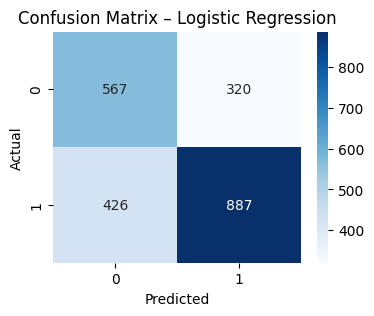

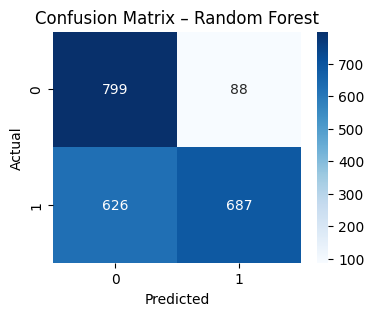

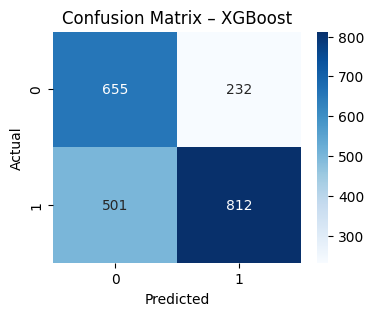

In [55]:
for name, res in results.items():
    cm = confusion_matrix(y_test, res["y_pred"])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


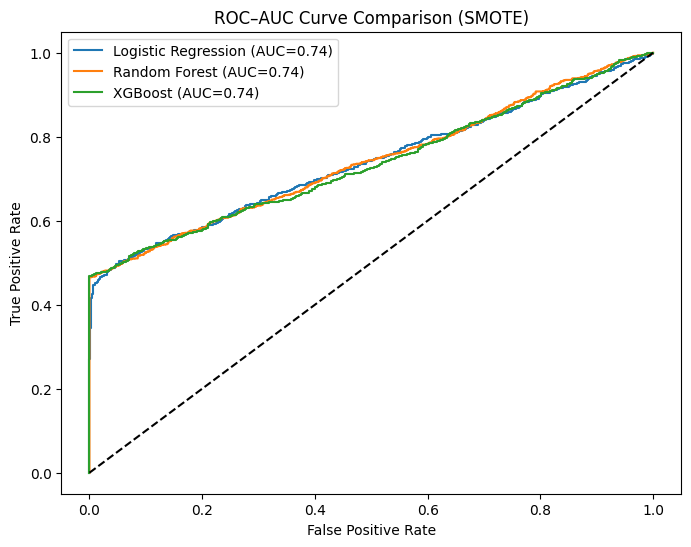

In [53]:
plt.figure(figsize=(8,6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve Comparison (SMOTE)")
plt.legend()
plt.show()


In [54]:
best_model_name = max(results, key=lambda x: results[x]["F1-Score"])
best_model = best_models[best_model_name]

with open("best_model_smote.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Final Selected Model:", best_model_name)


Final Selected Model: Logistic Regression
